# Degradation robustness: InternVL3.5-8B vs Gemma 4 12B W4A16

How does extraction accuracy and throughput hold up as document image quality falls?

**Receipts only, by construction.** `degraded_20260811` is 55 receipts x 3 severity tiers.
Bank statements and invoices are never degraded -- SDG's rationale is that receipts are the
only document type users photograph; statements and invoices arrive as clean PDFs.

That suits the question: receipts are the one type where both models tie at 1.000 median F1
on clean images, so degradation is precisely the test that breaks the tie.

**Ground truth is identical across tiers** -- distortion never changes the answer. The only
variable is image quality.

| Tier | Suffix | Ink bleed | Paper | Warp | Camera |
|---|---|---|---|---|---|
| clean | -- | -- | -- | -- | -- |
| light | `_v1` | 0.05-0.15 | lighting gradient | 1-3%, +/-3 deg | blur 0.2-0.5, JPEG 85-95 |
| moderate | `_v2` | 0.15-0.30 | gradient + cast shadow | 3-6%, +/-8 deg | blur 0.4-0.8, JPEG 65-80 |
| heavy | `_v3` | 0.30-0.50 | fold + gradient + shadow | 6-10%, +/-14 deg | blur 0.7-1.3, JPEG 50-65 |

`heavy` is deliberately calibrated to be **hard but not impossible** -- the generator config
records tuning it back when a fold obscured the supplier name, on the principle that "a field
a careful human cannot read is measuring noise rather than robustness".

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


def repo_root() -> Path:
    """Find the LMM_POC checkout by walking up from the working directory.

    Jupyter sets the kernel's cwd to the notebook's own directory, so
    `import common` fails unless whoever launched the kernel exported
    PYTHONPATH -- which nbconvert does and an IDE does not.
    """
    for directory in (Path.cwd(), *Path.cwd().parents):
        if (directory / "common" / "field_schema.py").is_file():
            return directory
    raise ModuleNotFoundError(
        f"Could not find the LMM_POC checkout from {Path.cwd()}.\n"
        "  Expected: this notebook to sit inside the repository, so that some "
        "parent directory contains common/field_schema.py.\n"
        "  Fix: open the notebook from within the repo (notebooks/ is fine), or "
        "start the kernel with PYTHONPATH=/path/to/LMM_POC."
    )


REPO_ROOT = repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common.field_schema import get_field_schema  # noqa: E402

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        # Text as vector paths, so exported SVGs render identically on a
        # machine that lacks the font (PowerPoint, Keynote, Slides).
        "svg.fonttype": "path",
    }
)

# Categorical palette, validated rather than chosen by eye: CVD separation
# dE 20.0 (protan) / 29.4 (tritan), normal-vision dE 26.9 -- all well above the
# >=8 target. Colour follows the ENTITY: one fixed hue per model, never
# reassigned when a filter changes which series are drawn.
INTERNVL = "#4C72B0"
GEMMA = "#DD8452"
MODEL_COLOUR = {"InternVL3.5-8B": INTERNVL, "Gemma 4 12B W4A16": GEMMA}
MODELS = list(MODEL_COLOUR)

# The validator flags #DD8452 at 2.73:1 against a light surface -- below 3:1.
# That obligates relief, so every figure below carries direct value labels and
# every figure is backed by a table. It is not dismissable.

# Diverging ramp for the delta heatmap: the two model hues through a neutral
# grey midpoint, so a cell's colour still names the model it favours. Never a
# rainbow, and never a hue at the midpoint.
DELTA_CMAP = LinearSegmentedColormap.from_list("internvl_gemma", [INTERNVL, "#e8e8e6", GEMMA])

# Sequential (magnitude) ramp for the per-field heatmaps: one hue, light->dark.
FIELD_CMAP = "Blues"

# Fields the schema marks as requiring the highest accuracy. Read from the YAML
# rather than restated here -- config/field_definitions.yaml is the single
# source of truth, and a hard-coded copy would drift the moment it changed.
CRITICAL_FIELDS = set(get_field_schema().critical_fields)

TIERS = ["clean", "light", "moderate", "heavy"]
INK = "#2b2b2b"
MUTED = "#6b6b6b"

In [2]:
import os

# Where the output_* run directories live. LMM_EVAL_ROOT overrides outright.
# With nothing set, the known locations are searched in order.
SANDBOX_ROOT = Path("/home/jovyan/nfs_share/tod_2026/evaluation_data")
CANDIDATE_ROOTS = [
    SANDBOX_ROOT,  # on the box
    Path.home() / "Desktop" / "evaluation_data",  # a mirror of the box tree
    Path.home() / "Downloads",  # a loose copy of just the run dirs
]

# Any one run directory is enough to recognise a results tree.
SENTINEL = "output_gemma_synthetic"

RUN_DIRS = (
    "output_internvl_synthetic, output_internvl_degraded, "
    "output_gemma_synthetic, output_gemma_degraded"
)


def locate_root() -> Path:
    """Resolve the results root, failing with a diagnostic rather than a stack trace.

    MORE THAN ONE MATCH IS AN ERROR, not a preference order. Both
    ~/Desktop/evaluation_data and ~/Downloads can hold a results tree, and on
    2026-08-13 they held runs from either side of a fix -- picking one silently
    would have reported superseded numbers as current, with nothing to show that
    anything was wrong. Guessing here is the exact failure this whole comparison
    keeps tripping over, so it refuses to guess.
    """
    override = os.environ.get("LMM_EVAL_ROOT")
    if override:
        root = Path(override)
        if (root / SENTINEL).is_dir():
            return root
        raise FileNotFoundError(
            f"LMM_EVAL_ROOT is set to '{root}' but there is no {SENTINEL}/ inside it.\n"
            f"  Expected: a directory holding the four run directories ({RUN_DIRS}).\n"
            f"  Fix: point LMM_EVAL_ROOT at that directory, or unset it to search "
            f"the known locations."
        )

    found = [c for c in CANDIDATE_ROOTS if (c / SENTINEL).is_dir()]

    if len(found) == 1:
        return found[0]

    if len(found) > 1:
        listed = "\n            ".join(str(c) for c in found)
        raise FileNotFoundError(
            f"More than one results tree found, so which one is meant is ambiguous:\n"
            f"            {listed}\n"
            f"  Expected: exactly one location holding {SENTINEL}/.\n"
            f"  Fix: name the one you want, e.g.\n"
            f"       LMM_EVAL_ROOT={found[0]}\n"
            f"       (or delete the stale tree). This is deliberately an error: "
            f"choosing for you would silently score whichever run happened to be "
            f"first, which is how superseded numbers get reported as current."
        )

    searched = "\n            ".join(str(c) for c in CANDIDATE_ROOTS)
    raise FileNotFoundError(
        f"No results tree found. Searched:\n            {searched}\n"
        f"  Expected: one of them to hold the four run directories ({RUN_DIRS}).\n"
        f"  Fix: set LMM_EVAL_ROOT to wherever the results are, e.g. "
        f"LMM_EVAL_ROOT=$HOME/Desktop/evaluation_data."
    )


ROOT = locate_root()
print(f"results root: {ROOT}")

# One run per model per condition. The clean runs cover all three document
# types, so receipts are filtered out of them below; the degraded runs are
# receipts only. Separate output dirs per run: read_completed_images() resumes
# from image_name, so a shared dir would make the second run skip everything.
RUNS = {
    ("InternVL3.5-8B", "clean"): ROOT / "output_internvl_synthetic",
    ("InternVL3.5-8B", "degraded"): ROOT / "output_internvl_degraded",
    ("Gemma 4 12B W4A16", "clean"): ROOT / "output_gemma_synthetic",
    ("Gemma 4 12B W4A16", "degraded"): ROOT / "output_gemma_degraded",
}

TIER_BY_SUFFIX = {"_v1": "light", "_v2": "moderate", "_v3": "heavy"}


def tier_of(image_name: str) -> str:
    """Recover the severity tier from the filename suffix."""
    stem = Path(image_name).stem
    for suffix, tier in TIER_BY_SUFFIX.items():
        if stem.endswith(suffix):
            return tier
    return "clean"


def locate(out_dir: Path, filename: str) -> Path:
    """Find a result file whether or not the evaluation/ level is present.

    The evaluate stage writes into <out_dir>/evaluation/, but a results folder
    copied off the box is often flattened. Accept either rather than making the
    reader reshape their download.
    """
    for candidate in (out_dir / "evaluation" / filename, out_dir / filename):
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"{filename} not found under {out_dir} (checked ./ and ./evaluation/)\n"
        "  Has that run finished? Each model needs a degraded run plus a clean run."
    )


def read_jsonl(path: Path) -> list[dict]:
    with path.open() as handle:
        return [json.loads(line) for line in handle if line.strip()]

results root: /Users/tod/Desktop/evaluation_data


In [3]:
records: list[dict] = []

for (model, _condition), out_dir in RUNS.items():
    evaluations = read_jsonl(locate(out_dir, "evaluation_results.jsonl"))
    # processing_time is per image and lives with the extractions, not the scores.
    seconds = {
        r["image_name"]: r.get("processing_time")
        for r in read_jsonl(locate(out_dir, "cleaned_extractions.jsonl"))
    }

    for r in evaluations:
        if r.get("document_type") != "RECEIPT":
            continue  # clean runs carry all three types
        if r.get("error") or "median_f1" not in r:
            continue
        records.append(
            {
                "model": model,
                "tier": tier_of(r["image_name"]),
                "image_name": r["image_name"],
                "case": r["image_name"].split("_")[0],
                "overall_accuracy": r.get("overall_accuracy", np.nan),
                "median_f1": r.get("median_f1", np.nan),
                "seconds": seconds.get(r["image_name"], np.nan),
                "field_scores": r.get("field_scores", {}),
            }
        )

df = pd.DataFrame(records)
df["tier"] = pd.Categorical(df["tier"], categories=TIERS, ordered=True)

# Sanity: 55 receipts per model per tier. Anything else means a run is partial,
# or a degraded receipt was misclassified and dropped out of the RECEIPT filter.
counts = df.groupby(["model", "tier"], observed=True).size().unstack(fill_value=0)
counts

tier,clean,light,moderate,heavy
model,,,,
Gemma 4 12B W4A16,55,55,55,55
InternVL3.5-8B,55,55,55,55


## Summary table

The table is not decoration -- the validated palette carries a contrast warning, so every
figure below is backed by readable numbers.

In [4]:
summary = (
    df.groupby(["model", "tier"], observed=True)
    .agg(
        n=("image_name", "size"),
        overall_accuracy=("overall_accuracy", "mean"),
        median_f1=("median_f1", "mean"),
        sec_per_image=("seconds", "mean"),
    )
    .round(3)
)

# Throughput as a RATE. Images per minute reads "higher is better", matching
# accuracy's direction so the three panels are read the same way, and it is the
# number capacity planning needs ("how many receipts an hour?"). Seconds per
# image is kept alongside because latency is the other half of the question.
#
# Derived as 60 / mean(seconds), i.e. one engine's throughput. A DP=2
# deployment runs two engines concurrently, so the deployed rate is ~2x this.
summary["images_per_min"] = (60.0 / summary["sec_per_image"]).round(1)
summary = summary[["n", "overall_accuracy", "median_f1", "images_per_min", "sec_per_image"]]
summary

n  overall_accuracy  median_f1  images_per_min  \
model             tier                                                        
Gemma 4 12B W4A16 clean     55             0.975      1.000             6.5   
                  light     55             0.971      1.000             6.4   
                  moderate  55             0.946      1.000             6.4   
                  heavy     55             0.874      0.999             6.4   
InternVL3.5-8B    clean     55             0.913      1.000             4.5   
                  light     55             0.914      1.000             4.4   
                  moderate  55             0.884      1.000             4.4   
                  heavy     55             0.814      0.976             4.4   

                            sec_per_image  
model             tier                     
Gemma 4 12B W4A16 clean             9.203  
                  light             9.332  
                  moderate          9.358  
                  heavy             9.316  
InternVL3.5-8B    clean            13.339  
                  light            13.646  
                  moderate         13.614  
                  heavy            13.602

## Accuracy and throughput across tiers

**`overall_accuracy` is the primary metric.** `median_f1` is saturated for receipts -- both
models sit at exactly 1.000 on clean images and may stay pinned through the lighter tiers.
Leading with the saturated metric would draw two flat lines and hide the result.

Separate panels rather than a second y-axis: a dual-axis chart invites a comparison between
two incommensurable scales.

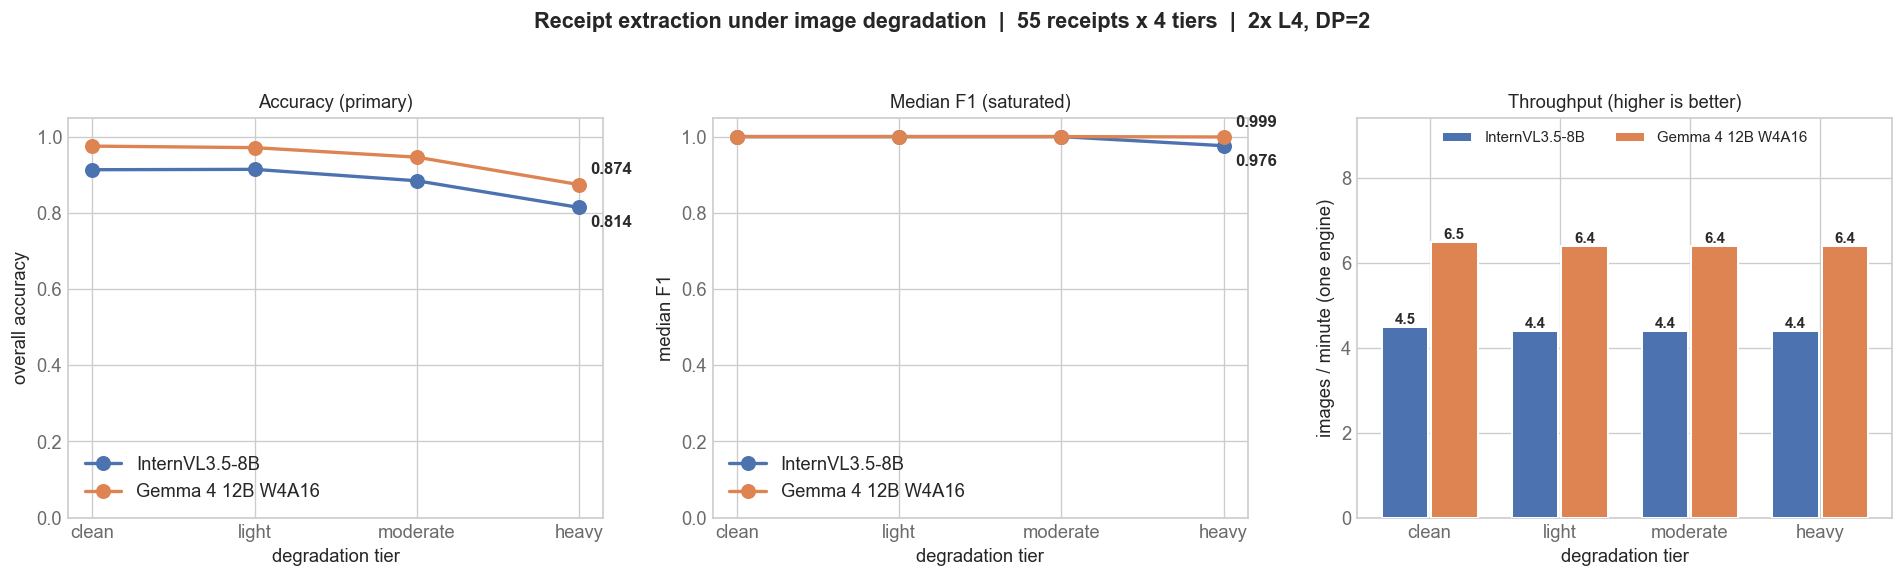

In [5]:
fig_curves, axes = plt.subplots(1, 3, figsize=(16, 4.6))
fig_curves.suptitle(
    "Receipt extraction under image degradation  |  55 receipts x 4 tiers  |  2x L4, DP=2",
    fontsize=13,
    fontweight="bold",
    y=1.04,
)

for ax, metric, title, ylab in (
    (axes[0], "overall_accuracy", "Accuracy (primary)", "overall accuracy"),
    (axes[1], "median_f1", "Median F1 (saturated)", "median F1"),
):
    # Which series ends on top? The direct labels are offset by THAT, not by
    # position in MODELS: keying off rank printed the upper line's value
    # underneath the lower line's, which reads as though they were swapped.
    finals = {m: summary.loc[m, metric].reindex(TIERS).iloc[-1] for m in MODELS}
    upper = max(finals, key=finals.get)

    for model in MODELS:
        series = summary.loc[model, metric].reindex(TIERS)
        ax.plot(
            TIERS,
            series.values,
            marker="o",
            markersize=8,
            linewidth=2,
            color=MODEL_COLOUR[model],
            label=model,
            zorder=3,
        )
        # Direct label at the line end, pushed away from the other series so
        # the two never overprint when the lines converge -- which they do
        # exactly when the result is most interesting.
        ax.annotate(
            f"{series.iloc[-1]:.3f}",
            xy=(len(TIERS) - 1, series.iloc[-1]),
            xytext=(7, 9 if model == upper else -9),
            textcoords="offset points",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=INK,
        )
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylab)
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False, loc="lower left")

# Throughput is a magnitude comparison, so bars rather than a line. Plotted as
# a RATE (images/minute) so taller means better here exactly as higher means
# better on the two accuracy panels -- a seconds-per-image panel would invert
# the reading halfway across the figure.
ax = axes[2]
width = 0.38
x = np.arange(len(TIERS))
for offset, model in zip((-width / 2, width / 2), MODELS):
    vals = summary.loc[model, "images_per_min"].reindex(TIERS)
    bars = ax.bar(
        x + offset,
        vals.values,
        width=width * 0.94,  # 2px-equivalent surface gap between adjacent bars
        color=MODEL_COLOUR[model],
        label=model,
        edgecolor="white",
        linewidth=1.2,
        zorder=3,
    )
    for bar, val in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=INK,
        )
ax.set_xticks(x, TIERS)
ax.set_ylabel("images / minute (one engine)")
ax.set_title("Throughput (higher is better)", fontsize=11)
# Headroom so the legend sits clear of the bars rather than over them.
ax.set_ylim(0, float(np.nanmax(summary["images_per_min"].values)) * 1.45)
ax.legend(frameon=False, loc="upper center", ncols=2, fontsize=9)

for ax in axes:
    ax.tick_params(colors=MUTED)
    ax.set_xlabel("degradation tier")

plt.tight_layout()
plt.show()

## Which fields break first?

Degradation rarely hits every field equally. A hypothesis worth testing: `BUSINESS_ABN`
(11 digits, no redundancy -- one misread character fails the field) should degrade before
`SUPPLIER_NAME`, which a model can recover semantically from partial strokes.

Sequential ramp, one hue light-to-dark, because the quantity is magnitude. Every cell is
labelled, which is the convention for a matrix and also discharges the contrast warning.

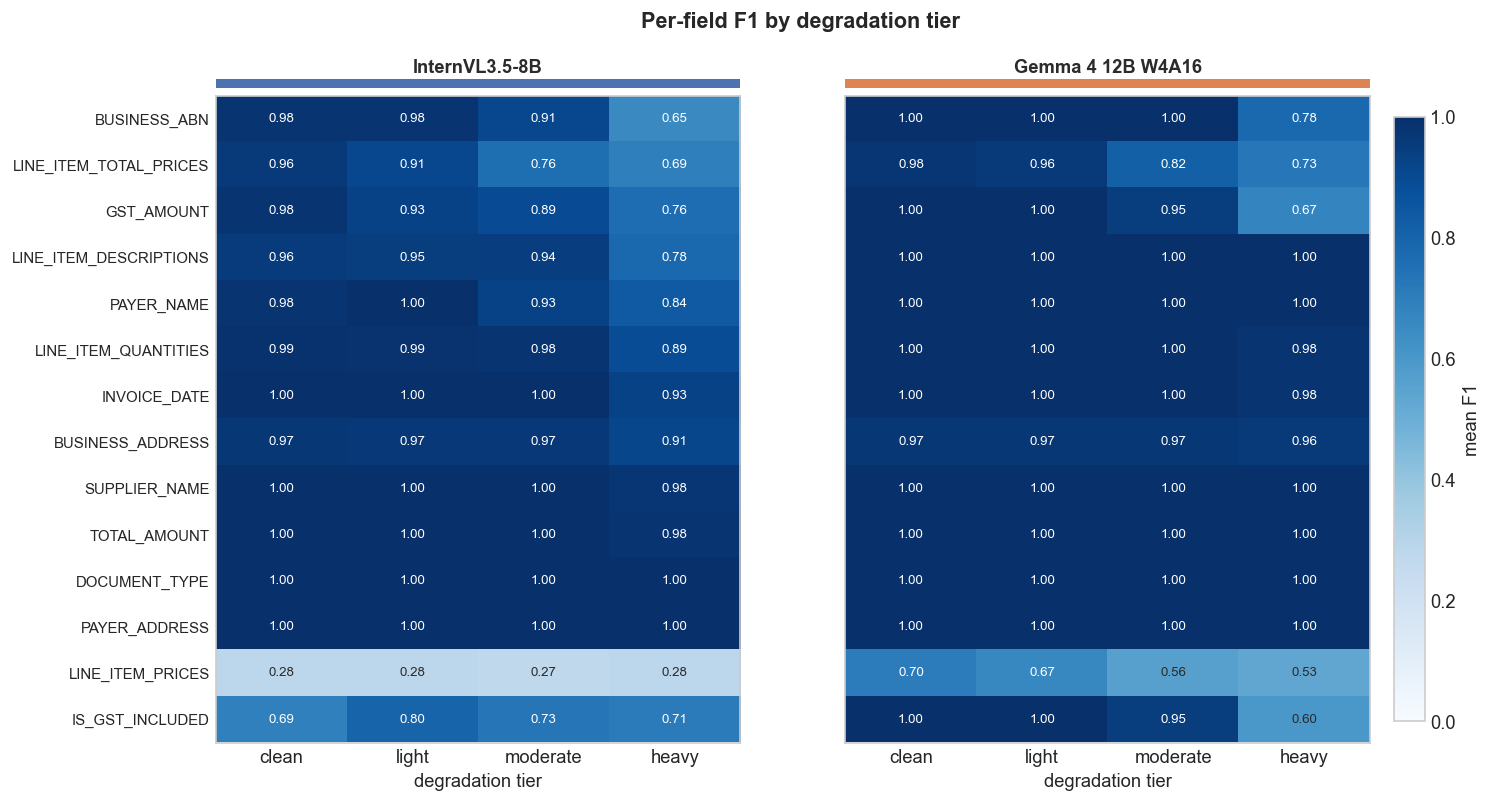

In [6]:
def field_matrix(model: str) -> pd.DataFrame:
    """Mean per-field F1 for one model, fields x tiers."""
    columns = {}
    for tier in TIERS:
        subset = df[(df["model"] == model) & (df["tier"] == tier)]
        collected: dict[str, list[float]] = {}
        for scores in subset["field_scores"]:
            for field, score in scores.items():
                collected.setdefault(field, []).append(score.get("f1_score", np.nan))
        columns[tier] = {f: float(np.nanmean(v)) for f, v in collected.items()}
    matrix = pd.DataFrame(columns).reindex(columns=TIERS)
    # Order fields by how far they fall, worst-hit at the top.
    return (
        matrix.assign(_drop=matrix["clean"] - matrix["heavy"])
        .sort_values("_drop", ascending=False)
        .drop(columns="_drop")
    )


matrices = {model: field_matrix(model) for model in MODELS}

fig_fields, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
fig_fields.suptitle("Per-field F1 by degradation tier", fontsize=13, fontweight="bold", y=0.98)

for ax, model in zip(axes, MODELS):
    matrix = matrices[model].reindex(matrices[MODELS[0]].index)
    im = ax.imshow(matrix.values, cmap=FIELD_CMAP, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(TIERS)), TIERS)
    ax.set_yticks(range(len(matrix.index)), matrix.index, fontsize=9)
    ax.set_xlabel("degradation tier")
    # Title in ink; a coloured accent rule above the panel carries identity.
    # Text never wears the series colour.
    ax.set_title(model, fontsize=11, color=INK, fontweight="bold", pad=14)
    ax.add_patch(
        plt.Rectangle(
            (0, 1.012),
            1,
            0.014,
            transform=ax.transAxes,
            color=MODEL_COLOUR[model],
            clip_on=False,
            linewidth=0,
        )
    )
    ax.grid(False)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.values[i, j]
            if np.isnan(value):
                continue
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                # Ink on light cells, surface on dark ones -- text never wears
                # the series colour.
                color="white" if value > 0.6 else INK,
            )

fig_fields.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="mean F1")
plt.show()

## Where the models differ

Diverging ramp -- two hues through a neutral grey midpoint, with each pole in its model's
own colour, so a cell's hue still names the model it favours. Grey means the two are level.

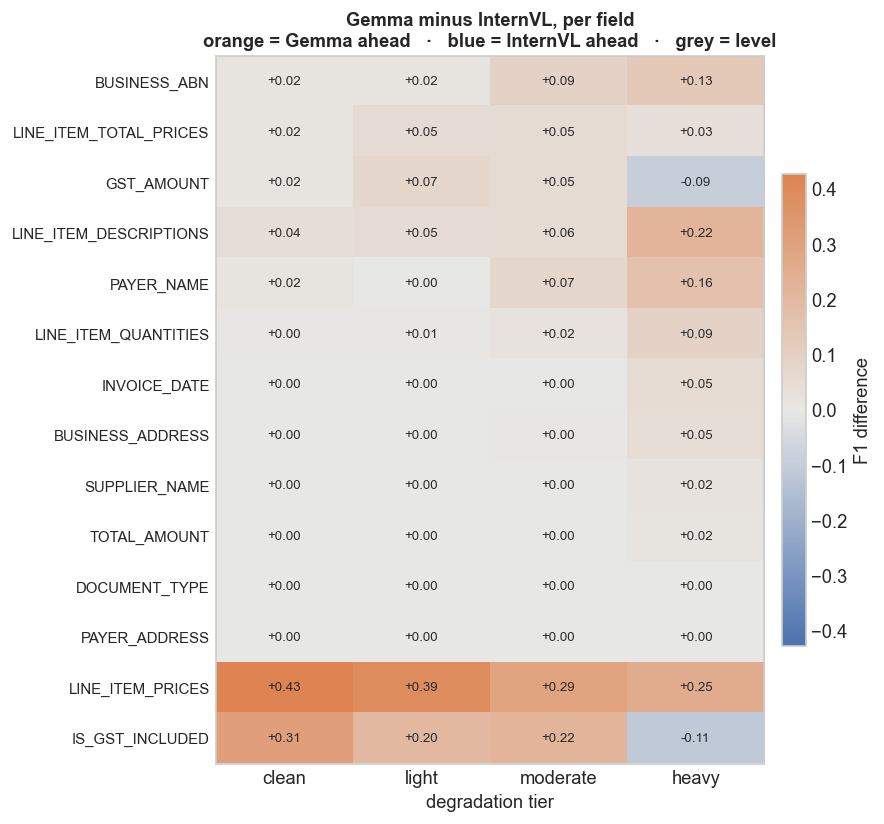

,clean,light,moderate,heavy
BUSINESS_ABN,0.018,0.018,0.091,0.127
LINE_ITEM_TOTAL_PRICES,0.018,0.053,0.055,0.033
GST_AMOUNT,0.018,0.073,0.055,-0.091
LINE_ITEM_DESCRIPTIONS,0.044,0.053,0.056,0.220
PAYER_NAME,0.018,0.000,0.073,0.164
LINE_ITEM_QUANTITIES,0.004,0.008,0.021,0.093
INVOICE_DATE,0.000,0.000,0.000,0.055
BUSINESS_ADDRESS,0.001,0.002,0.003,0.046
SUPPLIER_NAME,0.002,0.001,0.001,0.020
TOTAL_AMOUNT,0.000,0.000,0.000,0.018


In [7]:
delta = (matrices["Gemma 4 12B W4A16"] - matrices["InternVL3.5-8B"]).reindex(matrices[MODELS[0]].index)
limit = float(np.nanmax(np.abs(delta.values))) or 1.0

fig_delta, ax = plt.subplots(figsize=(7.5, 7))
im = ax.imshow(delta.values, cmap=DELTA_CMAP, vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(len(TIERS)), TIERS)
ax.set_yticks(range(len(delta.index)), delta.index, fontsize=9)
ax.set_title(
    "Gemma minus InternVL, per field\norange = Gemma ahead   ·   blue = InternVL ahead   ·   grey = level",
    fontsize=11,
    fontweight="bold",
)
ax.grid(False)
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        value = delta.values[i, j]
        if np.isnan(value):
            continue
        ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=8, color=INK)

fig_delta.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="F1 difference")
ax.set_xlabel("degradation tier")
plt.tight_layout()
plt.show()

delta.round(3)

## The same difference, as one ranked list

The heatmap answers "where and when", but reading a ranking out of a colour grid is work. A
lollipop chart answers the headline question directly -- **which fields does each model win,
and by how much** -- by putting every field on one axis, sorted.

Adapted from `notebooks_v2/lmmpoc_layoutlm_comparison.ipynb` in the old-history repo (commit
`a4126fa`), with two changes:

* **Model hues instead of green/red.** The original coloured by sign. Measured with the
  palette validator, green/red separates at ΔE 10.7 under deuteranopia against 20.0 for the
  blue/orange pair already used here -- roughly half, under the commonest deficiency. Colour
  also stays tied to the *entity* this way, so a dot's hue names the model it favours. Grey is
  the neutral midpoint: a field whose number rounds to 0.0% is level, and colouring it as a
  win would claim a lead that is not there.
* **Averaged across all four tiers**, since that is this notebook's whole dataset. The heatmap
  above remains the place to see a field that behaves differently at one tier.

Bold labels with a heavier ring are the schema's `critical_fields`, read from
`config/field_definitions.yaml` rather than restated here.

> **Every bar now points the same way**, which was not true of any earlier version of this
> chart. No receipt field favours InternVL; the smallest are level (`DOCUMENT_TYPE` and
> `PAYER_ADDRESS` at 0.0%). Earlier readings showed large bars in both directions, and every
> one of those turned out to be instrumentation rather than capability — `LINE_ITEM_QUANTITIES`
> sat at **-41.4%** before the `3x` decoration was compared as a number rather than a string,
> and is now +3.1%.
>
> **The two largest bars are instruction-following, not reading.** `LINE_ITEM_PRICES` (+34.0%)
> is the widest: the prompt asks for a unit price only where a line's quantity is 1, and Gemma
> applies that per line while InternVL writes `NOT_FOUND` everywhere on all 55 receipts.
> `IS_GST_INCLUDED` (+15.5%) is next. Both models read the documents; they differ in following
> a compound rule about where to put what they read.
>
> **The four critical fields are all but level** — `BUSINESS_ABN` +6.4%, `GST_AMOUNT` +1.4%,
> `SUPPLIER_NAME` +0.6%, `TOTAL_AMOUNT` +0.5%. On the values the schema says matter most, the
> two models are close to interchangeable.

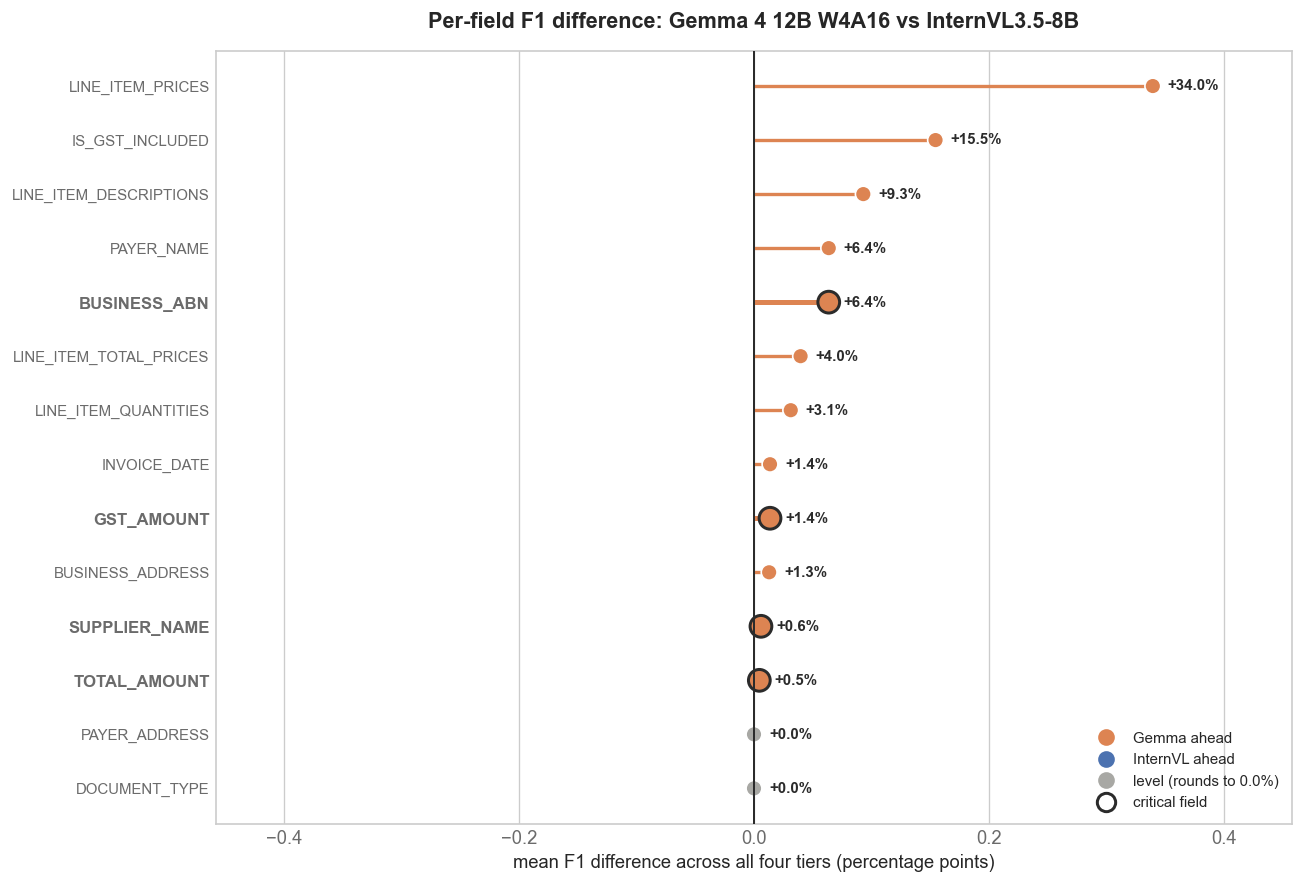

,mean F1 difference (Gemma - InternVL)
DOCUMENT_TYPE,0.000
PAYER_ADDRESS,0.000
TOTAL_AMOUNT,0.005
SUPPLIER_NAME,0.006
BUSINESS_ADDRESS,0.013
GST_AMOUNT,0.014
INVOICE_DATE,0.014
LINE_ITEM_QUANTITIES,0.031
LINE_ITEM_TOTAL_PRICES,0.040
BUSINESS_ABN,0.064


In [8]:
# Mean across the four tiers, ascending so the largest Gemma win lands at the top.
ranked = delta.mean(axis=1).sort_values()
y_pos = np.arange(len(ranked))

is_critical = [field in CRITICAL_FIELDS for field in ranked.index]

# A diverging encoding needs its neutral midpoint. Colouring `value >= 0` as a
# Gemma win painted TOTAL_AMOUNT, PAYER_ADDRESS and DOCUMENT_TYPE orange while
# their labels read "+0.0%" -- the legend then claims a lead that is not there.
# The cut-off is the one the printed label uses, so a dot is grey exactly when
# its number rounds to zero.
LEVEL = "#a8a8a4"
LEVEL_EPS = 0.0005


def dot_colour(value: float) -> str:
    if abs(value) < LEVEL_EPS:
        return LEVEL
    return GEMMA if value > 0 else INTERNVL


colours = [dot_colour(value) for value in ranked.values]

fig_lolli, ax = plt.subplots(figsize=(11, 7.5))

# Stem then dot. Critical fields get a heavier stem and a dark ring, so they
# are findable without colour doing the work.
ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=ranked.values,
    color=colours,
    linewidth=[3.0 if c else 2.0 for c in is_critical],
    zorder=2,
)
ax.scatter(
    ranked.values,
    y_pos,
    color=colours,
    s=[170 if c else 90 for c in is_critical],
    edgecolors=[INK if c else "white" for c in is_critical],
    linewidths=[1.8 if c else 1.0 for c in is_critical],
    zorder=3,
)
ax.axvline(0, color=INK, linewidth=1.2, zorder=4)

# Direct value labels on every dot -- the palette carries a contrast warning,
# so the numbers are obligatory relief, not decoration.
for y, value in zip(y_pos, ranked.values):
    ax.annotate(
        f"{value:+.1%}",
        xy=(value, y),
        xytext=(9 if value >= 0 else -9, 0),
        textcoords="offset points",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9,
        fontweight="bold",
        color=INK,
    )

ax.set_yticks(y_pos, ranked.index, fontsize=9)
for label, critical in zip(ax.get_yticklabels(), is_critical):
    if critical:
        label.set_fontweight("bold")
        label.set_fontsize(10)

# Symmetric limits: a diverging scale that is wider on one side exaggerates it.
span = float(np.nanmax(np.abs(ranked.values))) or 1.0
ax.set_xlim(-span * 1.35, span * 1.35)
ax.set_xlabel("mean F1 difference across all four tiers (percentage points)", fontsize=11)
ax.set_title(
    "Per-field F1 difference: Gemma 4 12B W4A16 vs InternVL3.5-8B",
    fontsize=13,
    fontweight="bold",
    pad=14,
)
ax.grid(axis="y", visible=False)
ax.tick_params(colors=MUTED)

# Two encodings, so two legend groups: hue names the model, ring names criticality.
legend_elements = [
    Line2D([0], [0], marker="o", linestyle="none", color=GEMMA, markersize=9, label="Gemma ahead"),
    Line2D([0], [0], marker="o", linestyle="none", color=INTERNVL, markersize=9, label="InternVL ahead"),
    Line2D([0], [0], marker="o", linestyle="none", color=LEVEL, markersize=9, label="level (rounds to 0.0%)"),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        color="white",
        markersize=11,
        markeredgecolor=INK,
        markeredgewidth=1.8,
        label="critical field",
    ),
]
ax.legend(handles=legend_elements, loc="lower right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

display(ranked.round(3).to_frame("mean F1 difference (Gemma - InternVL)"))

## Five scoring artefacts, and what they cost

The per-field view kept exposing fields that failed for **both** models at **every** tier,
including clean. None was a perception failure. All five are recorded because the pattern
matters more than any one of them: **a value compared as a string when it was not one, or a
pipeline step reshaping output the model had already got right.**

**1. `BUSINESS_ADDRESS` — FIXED (`fa00731`).** Ground truth writes
`384 Bailey Cres, Paddington QLD 4064`; both models return the same string without the comma.
It scored 0.000 because `calculate_field_accuracy_f1` imported `Levenshtein` inside a
try/except and fell back to EXACT MATCH — and that package is declared in no environment file
here, so the fallback was always the live path and the ANLS branch was dead code. Every
address, name and description in every run had been scored by string equality. Now 0.94-0.97.

**2. `LINE_ITEM_DESCRIPTIONS` — FIXED (`a8ab408`, `34c00f7`).** The field was missing from
`transaction_list_fields` while the sort group already treated it as part of the register.
Adding it alone made things *worse*: matching by edit distance alone dropped receipts from
85% to 34%, because receipts prefix the quantity (`2x <item>`) and one extra token barely
moves a word-overlap score but costs 0.18 of edit-distance similarity. The two measures fail
on opposite error types, so an item now matches if **either** passes.

**3. `LINE_ITEM_QUANTITIES` — FIXED (`bb402a8`, `4c4bb32`).** Gemma wrote `3x | 1x | 2x`
against a ground truth of `3 | 1 | 2` — every value correct, the field scored 0.000 on 29 of
55 receipts. The prompt specified no format at all. It now asks for digits, and the parser
strips multiplier decoration on both parse paths. Gemma 0.365 → 0.993.

**4. `LINE_ITEM_TOTAL_PRICES` — FIXED (`50b10d6`).** InternVL returned `9.72` where ground
truth writes `$9.72`: correct values, missing currency symbol, scored 0.000 on all 55
receipts while Gemma — which emits `$` — scored 0.987. The field is declared monetary in
`field_definitions.yaml`, but list items were compared by asking "is this a
`transaction_list` field?" and otherwise falling through to text. A structural question
standing in for a semantic one. InternVL 0.165 → 0.959.

**5. The cleaner shifted whole columns — FIXED (`4f178fe`).** Positional `NOT_FOUND`
placeholders were preserved only for names starting `TRANSACTION_AMOUNTS`, plus
`ACCOUNT_BALANCE`. Every other list lost them, shortening the column and shifting every value
after it out of alignment with its siblings. Gemma returned

```
raw     NOT_FOUND | $111.69 | NOT_FOUND | NOT_FOUND | $12.87
ground  NOT_FOUND | $111.69 | NOT_FOUND | NOT_FOUND | $12.87
cleaned $111.69 | $12.87            <- what the scorer saw
```

— a character-perfect extraction scored as two misplaced values.

### What remains open

**`LINE_ITEM_PRICES` is no longer an artefact, but it is not a reading test either.** Ground
truth now carries `NOT_FOUND` wherever the receipt does not print a unit price, which is every
line with a quantity above 1 — the earlier answer key held a *derived* value (line total ÷
quantity) that appears nowhere on the page, so a model reporting what it could see was marked
wrong. With that fixed the field measures whether a model applies a per-line condition, and
that is where the two genuinely differ (0.616 vs 0.277).

The table below shows the comparison is robust to excluding the two fields with the longest
artefact history.

In [9]:
EXCLUSIONS = {
    "all 14 fields": set(),
    "less BUSINESS_ADDRESS": {"BUSINESS_ADDRESS"},
    "less both artefacts": {"BUSINESS_ADDRESS", "LINE_ITEM_PRICES"},
}

rows = []
for model in MODELS:
    matrix = matrices[model]
    for tier in TIERS:
        row = {"model": model, "tier": tier}
        for label, excluded in EXCLUSIONS.items():
            keep = matrix.loc[~matrix.index.isin(excluded), tier]
            row[label] = round(float(np.nanmean(keep.values)), 3)
        rows.append(row)

adjusted = pd.DataFrame(rows).set_index(["model", "tier"])
retained = (
    adjusted.groupby("model", observed=True)
    .apply(lambda g: g.loc[(slice(None), "heavy"), :].iloc[0] / g.loc[(slice(None), "clean"), :].iloc[0])
    .round(3)
)
print("mean per-field F1")
display(adjusted)
print("\nfraction retained at heavy (heavy / clean)")
display(retained)

mean per-field F1


all 14 fields  less BUSINESS_ADDRESS  \
model             tier                                             
InternVL3.5-8B    clean             0.913                  0.909   
                  light             0.914                  0.910   
                  moderate          0.884                  0.878   
                  heavy             0.814                  0.807   
Gemma 4 12B W4A16 clean             0.975                  0.975   
                  light             0.971                  0.971   
                  moderate          0.946                  0.944   
                  heavy             0.874                  0.867   

                            less both artefacts  
model             tier                           
InternVL3.5-8B    clean                   0.962  
                  light                   0.963  
                  moderate                0.928  
                  heavy                   0.851  
Gemma 4 12B W4A16 clean                   0.998  
                  light                   0.996  
                  moderate                0.976  
                  heavy                   0.895


fraction retained at heavy (heavy / clean)


,all 14 fields,less BUSINESS_ADDRESS,less both artefacts
model,,,
Gemma 4 12B W4A16,0.896,0.889,0.897
InternVL3.5-8B,0.892,0.888,0.885


## Export for slides

SVG with text rendered as vector paths, so the figures survive a machine that lacks the
font. PNG alongside for anywhere SVG is awkward.

In [10]:
import os

FIG_DIR = Path(os.environ.get("LMM_FIG_DIR", "figures"))
FIG_DIR.mkdir(parents=True, exist_ok=True)

for name, figure in (
    ("degradation_curves", fig_curves),
    ("per_field_f1", fig_fields),
    ("per_field_delta", fig_delta),
    ("per_field_lollipop", fig_lolli),
):
    for extension in ("svg", "png"):
        path = FIG_DIR / f"{name}.{extension}"
        figure.savefig(path, format=extension, bbox_inches="tight", dpi=200)
        print(f"wrote {path}")

wrote figures/degradation_curves.svg


wrote figures/degradation_curves.png


wrote figures/per_field_f1.svg


wrote figures/per_field_f1.png
wrote figures/per_field_delta.svg


wrote figures/per_field_delta.png
wrote figures/per_field_lollipop.svg
wrote figures/per_field_lollipop.png


## Key takeaways

_Run of 2026-08-13, re-cleaned and re-scored after four pipeline fixes: the quantity format
rule and multiplier normaliser (`bb402a8`, `4c4bb32`), the unit-price rule and monetary
comparison for list fields (`50b10d6`), and the cleaner no longer shifting index-aligned
columns (`4f178fe`)._

| Metric | InternVL3.5-8B | Gemma 4 12B W4A16 | Winner |
|---|---|---|---|
| Accuracy, clean | 0.913 | **0.975** | Gemma |
| Accuracy, light | 0.914 | **0.971** | Gemma |
| Accuracy, moderate | 0.884 | **0.946** | Gemma |
| Accuracy, heavy | 0.814 | **0.874** | Gemma |
| Median F1, heavy | 0.976 | **0.999** | tie in practice |
| Retained at heavy | 89.2% | 89.6% | level |
| Throughput | 4.4 - 4.5 img/min | **6.4 - 6.5 img/min** | Gemma, ~46% more |
| Seconds per image | 13.3 - 13.6 | **9.2 - 9.4** | Gemma, ~31% less |
| Classification under degradation | 165/165 | 165/165 | tie |

### Most of the gap we spent a week measuring was our own instrumentation

Worth stating before any comparison, because it changes how much weight a single number
carries. Four separate defects were each scoring a correct extraction as wrong, and every one
of them was the same shape -- a value compared as a string when it was not one, or a pipeline
step reshaping output the model had already got right:

| defect | effect when found |
|---|---|
| `Levenshtein` import fell back to exact match | every address, name and description scored by string equality |
| descriptions not in the register, then matched by one measure | receipts fell 85% to 34% on a "fix" |
| `3x` quantity decoration compared as text | Gemma 0.365 where it had read every value correctly |
| monetary list fields compared as text | InternVL 0.165 on line totals, for a missing `$` |
| cleaner dropped positional placeholders | a character-perfect answer scored as misplaced values |

Gemma's clean-receipt accuracy moved 0.847 → 0.975 across those fixes and InternVL's 0.752 →
0.913. **The ranking never changed** — Gemma led at every tier before and after — but the
margin narrowed from ~10 points to ~6, and several fields that looked like capability gaps
turned out to be formatting. Treat any single field difference as provisional until it has
survived a look at the raw output.

### The models differ on TABLES, not on VALUES

Pooled across all four tiers, the ten **scalar** receipt fields differ between the models by a
mean of **3.3 points**, worst case 15.5 (`IS_GST_INCLUDED`). The four `LINE_ITEM_*` **list**
fields differ by a mean of **12.6 points**, worst case 34.0. Still roughly a fourfold gap in
spread, splitting on one question: *is this field a single value, or a column of values?* The
ratio has narrowed from sevenfold as the instrumentation improved, which is itself a warning
about how much of the original effect was measurement.

The bank-statement notebook (`bank_debit_position_analysis.ipynb`) shows the split far more
sharply and identifies the mechanism. There the two scalar header fields are effectively tied
-- `DOCUMENT_TYPE` 1.000 for both, `STATEMENT_DATE_RANGE` 0.991 vs 0.945 in *InternVL's*
favour -- while all three columns of the transaction register separate by 36 to 46 points, and
match rate decays monotonically with row position for both models (Pearson *r* -0.91 to -0.96).

> **The difference between these models is not reading a value off a page. It is sustaining
> accuracy down a long table.** The scalar fields are the control group that proves it: where
> the document asks for one value, the models are interchangeable.

**Only the bank data demonstrates the long-table mechanism.** Receipts are short, so their list
gap is now mostly about *instruction-following* rather than tail-drop (below). Bank statements
show genuine positional decay over 20-40 rows. Same split, same practical conclusion --
**model choice matters most where the document is a table** -- but by different routes.

### Instruction-following is the clearest real difference

`LINE_ITEM_PRICES` is the largest remaining per-field gap (0.616 vs 0.277) and it is **not**
a reading difference. The receipt prints one amount per line, which is the line total; the
per-unit price appears only where the quantity is 1, and the prompt says exactly that. Gemma
applies the condition per line:

```
CASE003  Gemma  NOT_FOUND | $111.69 | NOT_FOUND | NOT_FOUND | $12.87
         truth  NOT_FOUND | $111.69 | NOT_FOUND | NOT_FOUND | $12.87
```

InternVL writes `NOT_FOUND` at every position, on all 55 receipts — it applies "not printed"
unconditionally and never notices that quantity 1 makes the printed amount the unit price. Its
score is flat at 0.273-0.278 across all four tiers precisely because its answer does not vary.

The same pattern appears on descriptions: after the prompt asked for item names without the
leading count, Gemma complied on every receipt (1.000) while InternVL still emitted `3x` style
prefixes on 48 of 55 (0.906). **Both models can read these documents; Gemma follows compound
instructions about where to put what it reads, and InternVL does so less reliably.** That is a
real and practically important difference, and it is the one thing here that survived every
instrumentation fix.

### The rest

**Neither model is meaningfully affected by light or moderate degradation.** Accuracy is nearly
flat from clean through moderate -- Gemma 0.975 / 0.971 / 0.946, InternVL 0.913 / 0.914 /
0.884. Only `heavy` bites, and even there both retain about 89% of clean accuracy.

**The two models are equally graceful under degradation.** Retention at heavy is 89.6% for
Gemma and 89.2% for InternVL. An earlier reading gave InternVL a visible edge here; that was an
artefact of Gemma being scored wrong on quantities it had read correctly at every tier.

**Gemma is more accurate at every tier and processes ~46% more images per minute.** Degradation
costs Gemma +1.2% time from clean to heavy and InternVL +2.0%, so the throughput gap is stable
rather than eroding under harder input.

**Bank statements reproduce exactly, three runs running.** Every bank per-field F1 and every
position-level statistic -- correlations, first-position rates, row-count outcomes, miss counts
-- is unchanged to three decimals across three end-to-end re-runs. Receipt numbers moved only
where a prompt or a pipeline step changed. Treat differences below ~0.002 as noise, and treat
the bank set as a usable regression baseline.

**Classification is untouched by degradation** -- 165/165 receipts correctly typed by both
models at every tier. Whatever degradation costs, it is not document identification.

## Confounds

State these wherever the numbers are quoted -- the comparison is controlled on data, ground
truth, scorer and hardware, but not on these:

- **Engine**: InternVL on vLLM 0.19.0, Gemma on 0.25.1.
- **Precision**: InternVL BF16, Gemma QAT W4A16.
- **Generation**: Gemma 4 is roughly a year newer (InternVL3.5 Aug 2025, Gemma 4 mid-2026),
  so part of any margin is generational rather than architectural.
- **Image handling**: InternVL uses 448-px pre-tiling (6-tile receipt budget); Gemma uses its
  own soft-token budget with pre-tiling off. Each is that model's correct configuration, not
  a handicap -- but they are not the same mechanism.
- **Prompt**: the receipt prompt is SHARED (`models/registry.py` gives every vLLM model
  `prompt_file=internvl3_prompts.yaml`), so every rule reached both models identically.
  Neither model has a prompt tuned to it, which is what makes the instruction-following
  difference above a fair comparison rather than an artefact of prompt effort.

`enforce_eager` is matched (`false`, CUDA graphs on) for both, so throughput is comparable.
Throughput figures are **per engine**: a DP=2 deployment runs two of them concurrently.

## Reading the result

Two outcomes would make the experiment uninformative rather than negative:

- **Both models hold at 1.000 through `heavy`** -- the tiers are too mild, and the finding is
  about the degradation config rather than the models.
- **Both collapse to near zero at `heavy`** -- the tier is too harsh to discriminate.

The tier was calibrated against rendered output to sit between those, but for human legibility
rather than for these models. That margin is now thin: excluding the two artefact fields Gemma
reaches 0.998 on clean and 0.996 at light, so this corpus is close to saturating for it and a
harder set would be needed to separate the models further at the milder tiers.